# Case Study 1 : Data Mining in Financial Data

**Financial Data Collection:** 
* Please collect five-year stock price data of at least 5 stocks. You can choose any stocks you'd like to analyze.
* You have multiple ways of collecting financial data with Python, here is a reference: https://www.alpharithms.com/python-financial-data-491110/
* Load the data you collect and start working on your idea.


# Problem: pick a data science problem that you plan to solve using Stock Price Data
* The problem should be important and interesting, which has a potential impact in some area.
* The problem should be solvable using the data available and data science solutions.

Please briefly describe in the following cell: what problem are you trying to solve? why this problem is important and interesting?

In [3]:
!pip install yfinance


  Using cached yfinance-0.2.52-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached multitasking-0.0.11-py3-none-any.whl.metadata (5.5 kB)
  Using cached peewee-3.17.8-py3-none-any.whl
  Using cached html5lib-1.1-py2.py3-none-any.whl.metadata (16 kB)
Using cached yfinance-0.2.52-py2.py3-none-any.whl (108 kB)
Using cached html5lib-1.1-py2.py3-none-any.whl (112 kB)
Using cached multitasking-0.0.11-py3-none-any.whl (8.5 kB)


In [1]:

import pandas as pd
import yfinance as yf

# List of Cybersecurity stocks to analyze
stocks = ['PANW', 'CHKP', 'CRWD', 'FTNT', 'ZS']

# date range for data collection
start_date = "2020-01-01"
end_date = "2025-01-01"

# Dictinary to store data fro each stock
data_frames = {}


for stock in stocks:
    ticker = yf.Ticker(stock)
    data = ticker.history(start=start_date, end=end_date)
    data["Stock"] = stock
    data_frames[stock] = data

# Combining all stock data into a single DataFrame
combined_data = pd.concat(data_frames.values())

# Saving CSV file

combined_data.to_csv("stock_price_data.csv")

print("Stock price data collected and saved to 'stock_price_data.csv'.")


problem_description = """
I want to determine which stock among Palo Alto Networks (PANW)
Check Point Software (CHKP)
CrowdStrike (CRWD)
Fortinet (FTNT)
Zscaler (ZS) performed the best over a five-year period (2020-2025) by analyzing historical stock price data. 

Why This Is Important and Interesting:
1. This analysis gives potential investors a clear picture of which stock has demonstrated consistent growth and stability.
2. It helps uncover financial market trends and patterns tied to these major corporations.
3. It provides an opportunity to enhance data science skills through tasks like prediction, trend analysis, and supporting informed decision-making.

By addressing this problem, we aim to guide stakeholders in making smarter investment choices based on key performance indicators such as cumulative returns, volatility, and risk-adjusted returns.
"""

print(problem_description)

reference_link = "https://www.alpharithms.com/python-financial-data-491110/"
print(f"Reference for data collection: {reference_link}")








Stock price data collected and saved to 'stock_price_data.csv'.

I want to determine which stock among Palo Alto Networks (PANW)
Check Point Software (CHKP)
CrowdStrike (CRWD)
Fortinet (FTNT)
Zscaler (ZS) performed the best over a five-year period (2020-2025) by analyzing historical stock price data. 

Why This Is Important and Interesting:
1. This analysis gives potential investors a clear picture of which stock has demonstrated consistent growth and stability.
2. It helps uncover financial market trends and patterns tied to these major corporations.
3. It provides an opportunity to enhance data science skills through tasks like prediction, trend analysis, and supporting informed decision-making.

By addressing this problem, we aim to guide stakeholders in making smarter investment choices based on key performance indicators such as cumulative returns, volatility, and risk-adjusted returns.

Reference for data collection: https://www.alpharithms.com/python-financial-data-491110/


# Data Collection/Processing: 

In [17]:


collected_data = pd.read_csv("stock_price_data.csv")
collected_data.dropna(inplace=True)

collected_data["Date"] = pd.to_datetime(collected_data["Date"], utc=True)

collected_data["Daily Return"] = collected_data.groupby("Stock")["Close"].pct_change()

collected_data.to_csv("processed_stock_price_data.csv", index=False)

print("Data cleaned and additional metrics calculated. Processed data saved to 'processed_stock_price_data.csv'.")




Data cleaned and additional metrics calculated. Processed data saved to 'processed_stock_price_data.csv'.


# Data Exploration: Exploring the Dataset

**Plot the daily, weekly and monthly returns of a set of stocks of your choice** 
* references:
    * https://www.investopedia.com/terms/y/yearly-rate-of-return-method.asp
    * https://www.fool.com/knowledge-center/how-to-calculate-a-monthly-return-on-investment/#:~:text=Take%20the%20ending%20balance%2C%20and,corresponds%20to%20your%20monthly%20return.
    * https://www.investopedia.com/terms/i/intraday-return.asp#:~:text=How%20Is%20Daily%20Return%20Calculated,price%2C%20then%20multiply%20by%20100. 


[*********************100%***********************]  5 of 5 completed


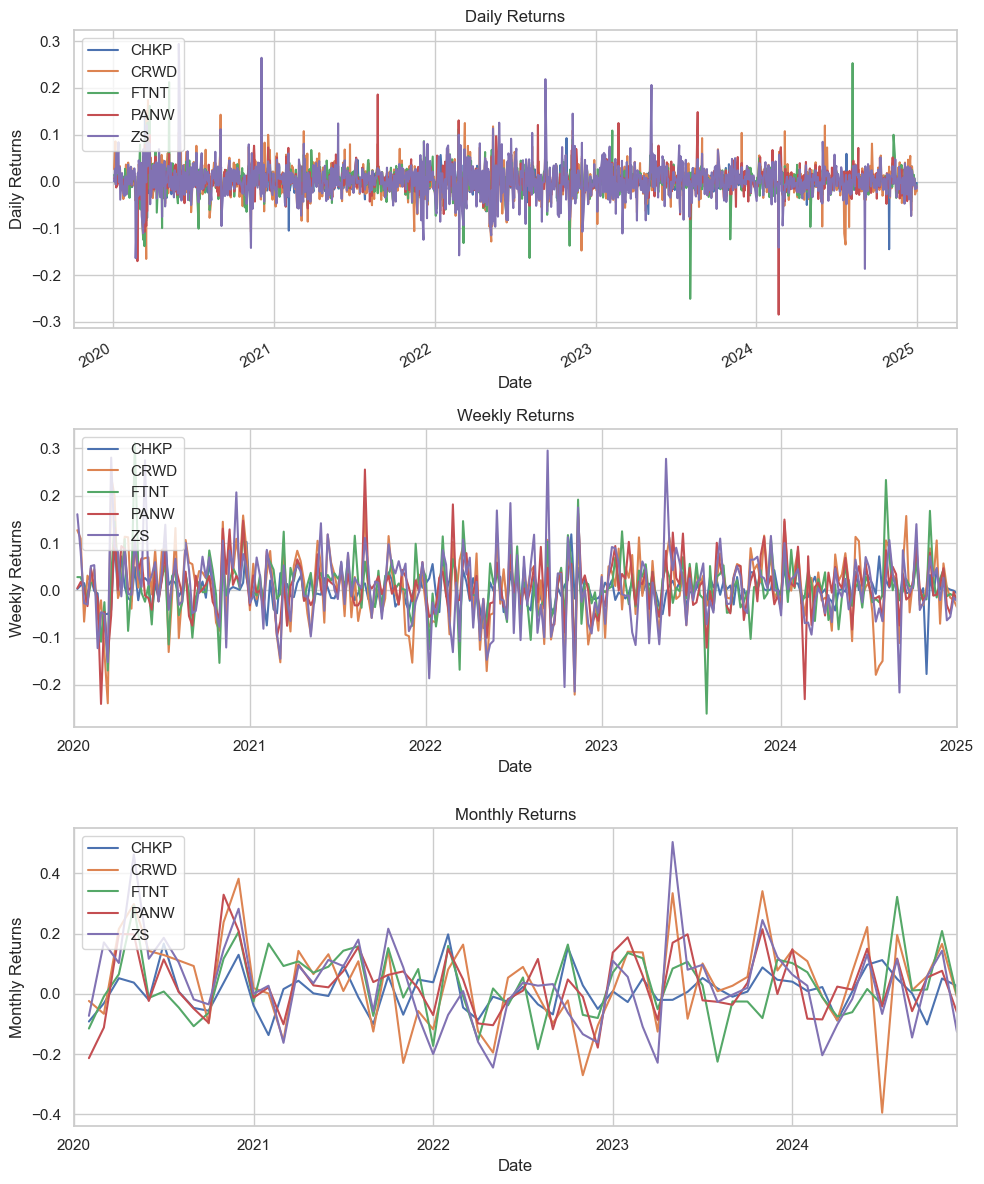

In [19]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style='whitegrid')

# Define stock tickers and date range
stocks = ['PANW', 'CHKP', 'CRWD', 'FTNT', 'ZS']
start_date = '2020-01-01'
end_date = '2025-01-01'

# Download stock data
data = yf.download(stocks, start=start_date, end=end_date)

# Access 'Close' for each stock from the multi-index
close_data = data['Close']

# Calculate daily returns
daily_returns = close_data.pct_change()

# weekly and monthly, and calculate returns
weekly_returns = close_data.resample('W').ffill().pct_change()
monthly_returns = close_data.resample('ME').ffill().pct_change()

# Create the plots
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Plot daily returns
daily_returns.plot(ax=axes[0], title="Daily Returns", xlabel="Date", ylabel="Returns", legend=True)
axes[0].legend(loc='upper left')
axes[0].set_ylabel('Daily Returns')

# Plot weekly returns
weekly_returns.plot(ax=axes[1], title="Weekly Returns", xlabel="Date", ylabel="Returns", legend=True)
axes[1].legend(loc='upper left')
axes[1].set_ylabel('Weekly Returns')

# Plot monthly returns
monthly_returns.plot(ax=axes[2], title="Monthly Returns", xlabel="Date", ylabel="Returns", legend=True)
axes[2].legend(loc='upper left')
axes[2].set_ylabel('Monthly Returns')

plt.tight_layout()
plt.show()


In [25]:
import yfinance as yf
import pandas as pd

# Define stock tickers
stocks = ['PANW', 'CHKP', 'CRWD', 'FTNT', 'ZS']

# Download stock data
start_date = '2020-01-01'
end_date = '2025-01-01'
data = yf.download(stocks, start=start_date, end=end_date)

# Print the column levels to understand structure
print("Column levels and structure:")
print(data.columns)



[*********************100%***********************]  5 of 5 completed

Column levels and structure:
MultiIndex([( 'Close', 'CHKP'),
            ( 'Close', 'CRWD'),
            ( 'Close', 'FTNT'),
            ( 'Close', 'PANW'),
            ( 'Close',   'ZS'),
            (  'High', 'CHKP'),
            (  'High', 'CRWD'),
            (  'High', 'FTNT'),
            (  'High', 'PANW'),
            (  'High',   'ZS'),
            (   'Low', 'CHKP'),
            (   'Low', 'CRWD'),
            (   'Low', 'FTNT'),
            (   'Low', 'PANW'),
            (   'Low',   'ZS'),
            (  'Open', 'CHKP'),
            (  'Open', 'CRWD'),
            (  'Open', 'FTNT'),
            (  'Open', 'PANW'),
            (  'Open',   'ZS'),
            ('Volume', 'CHKP'),
            ('Volume', 'CRWD'),
            ('Volume', 'FTNT'),
            ('Volume', 'PANW'),
            ('Volume',   'ZS')],
           names=['Price', 'Ticker'])


In [27]:
import yfinance as yf
import pandas as pd

# Download stock data for the compinies
tickers =['PANW', 'CHKP', 'CRWD', 'FTNT', 'ZS']
data = yf.download(tickers, start="2020-01-01", end="2025-01-01", actions=True)

# Check data see available columns
print(data.head())

# Adjust close prices manually using dividends and stock splits
adjusted_data = data.copy()

# Adjust for stock splits and dividends
for ticker in tickers:
    # Dividends adjustment: Add the dividend to the close price for each day
    adjusted_data[('Close', ticker)] = data[('Close', ticker)] + data[('Dividends', ticker)]
    
    # Stock splits adjustment: Divide the price by the stock split factor for each day
    adjusted_data[('Close', ticker)] = adjusted_data[('Close', ticker)] / (1 + data[('Stock Splits', ticker)])

# Display adjusted data
print(adjusted_data.head())


[*********************100%***********************]  5 of 5 completed

Price            Close                                             Dividends  \
Ticker            CHKP       CRWD       FTNT       PANW         ZS      CHKP   
Date                                                                           
2020-01-02  112.260002  49.439999  21.936001  39.235001  47.330002       0.0   
2020-01-03  112.290001  50.750000  22.242001  39.471668  47.380001       0.0   
2020-01-06  112.800003  55.110001  22.400000  40.043331  48.700001       0.0   
2020-01-07  112.029999  54.750000  22.378000  40.273335  48.400002       0.0   
2020-01-08  111.480003  55.660000  22.733999  39.761665  50.750000       0.0   

Price                           ... Stock Splits                       Volume  \
Ticker     CRWD FTNT PANW   ZS  ...         CHKP CRWD FTNT PANW   ZS     CHKP   
Date                            ...                                             
2020-01-02  0.0  0.0  0.0  0.0  ...          0.0  0.0  0.0  0.0  0.0   982700   
2020-01-03  0.0  0.0  0.0  0.0  ...

[*********************100%***********************]  5 of 5 completed


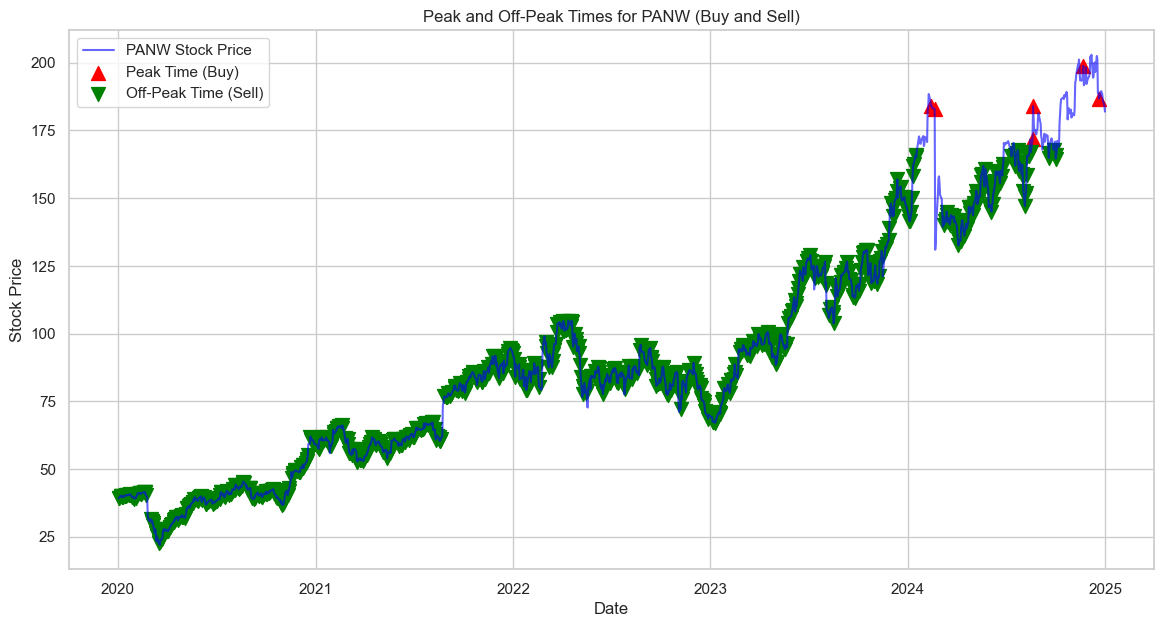

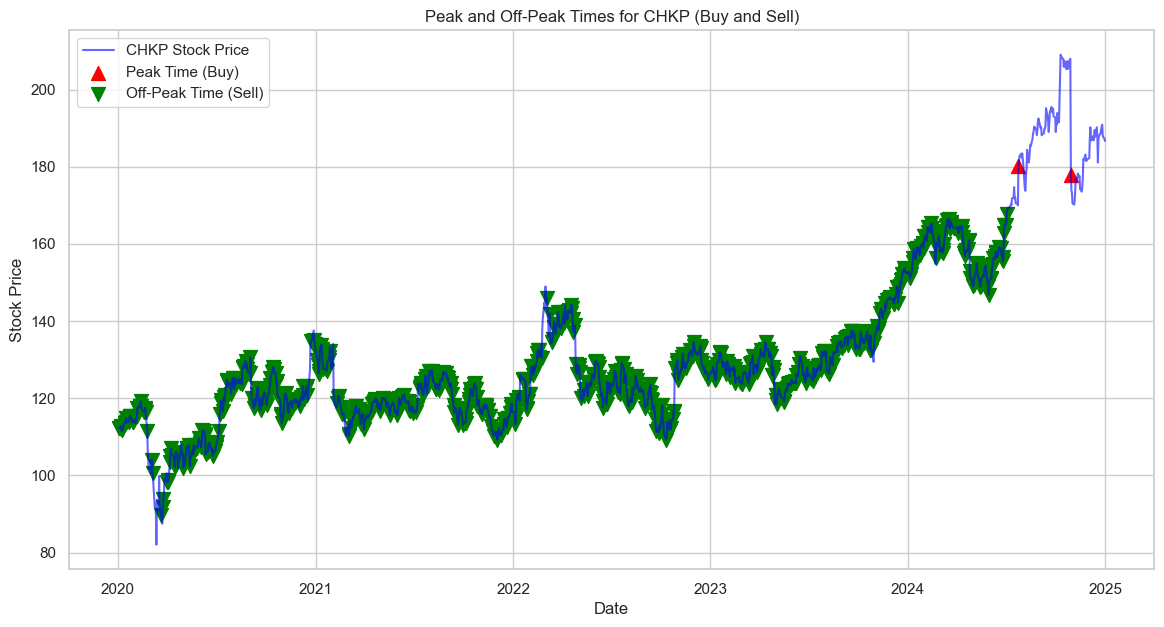

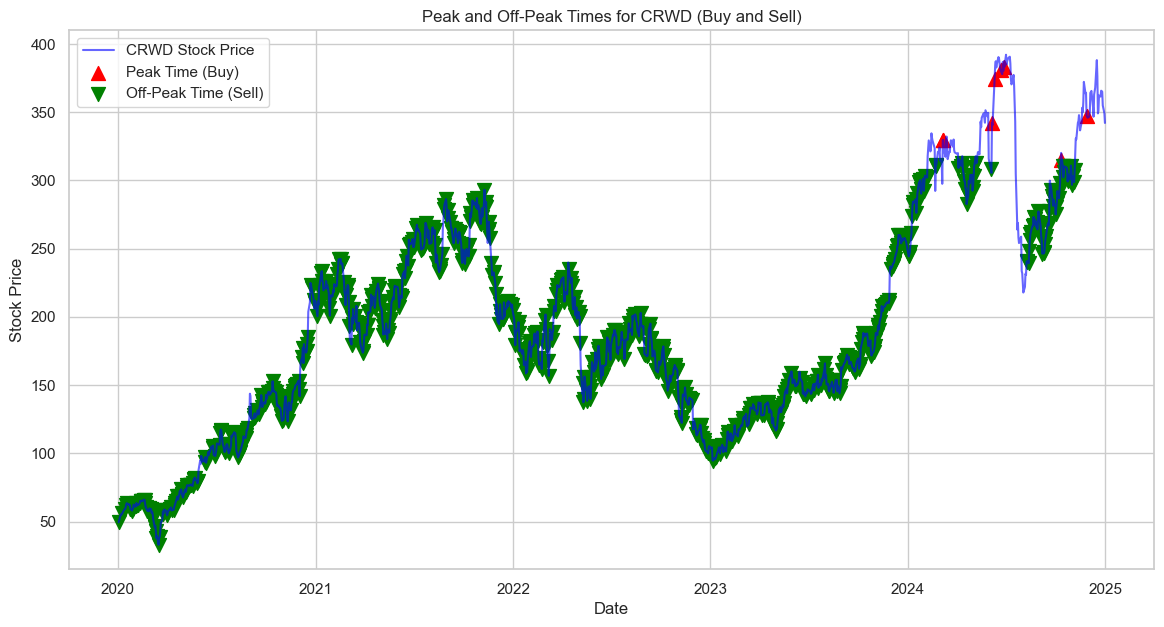

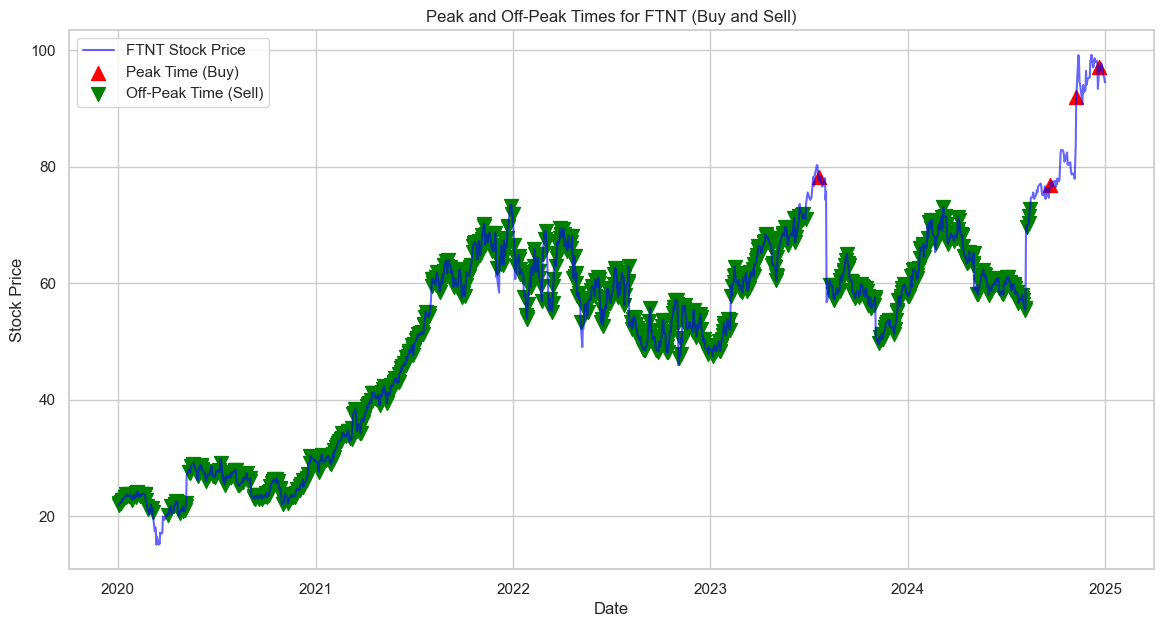

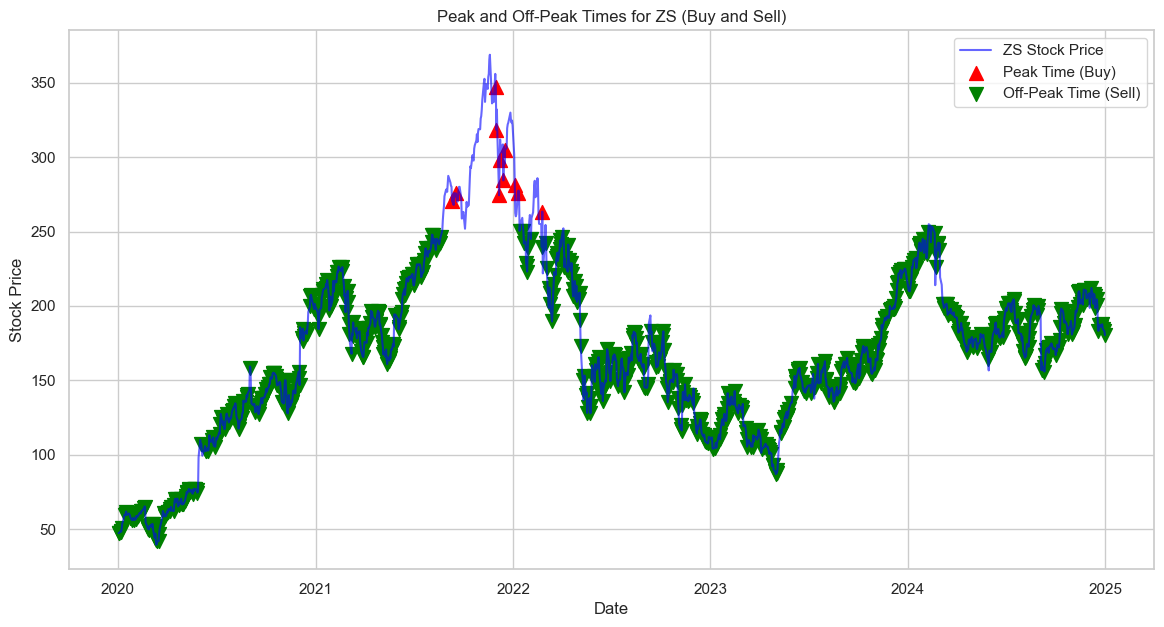

In [31]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# stock data fr companies
tickers = ['PANW', 'CHKP', 'CRWD', 'FTNT', 'ZS']
data = yf.download(tickers, start="2020-01-01", end="2025-01-01", group_by='ticker')

# Iterate over each ticker and plot the data
for ticker in tickers:
    # Extract data for specific ticker
    stock_data = data[ticker]
    stock_data = stock_data.reset_index() 
    
    # Set a threshold to identify peak and off-peak times (e.g., top 10% of prices and volumes)
    price_threshold = stock_data['Close'].quantile(0.90)  # Top 10% highest prices
    volume_threshold = stock_data['Volume'].quantile(0.90)  # Top 10% highest volumes

    # Identify peak and off-peak days based on price, volume thresholds
    peak_times = stock_data[(stock_data['Close'] >= price_threshold) & (stock_data['Volume'] >= volume_threshold)]
    off_peak_times = stock_data[(stock_data['Close'] < price_threshold) & (stock_data['Volume'] < volume_threshold)]

    # deta
    plt.figure(figsize=(14, 7))
    
    # stock closing prices
    plt.plot(stock_data['Date'], stock_data['Close'], label=f'{ticker} Stock Price', color='blue', alpha=0.6)

    # peak and off-peak times
    if not peak_times.empty:
        plt.scatter(peak_times['Date'], peak_times['Close'], color='red', label='Peak Time (Buy)', marker='^', s=100)
    if not off_peak_times.empty:
        plt.scatter(off_peak_times['Date'], off_peak_times['Close'], color='green', label='Off-Peak Time (Sell)', marker='v', s=100)

    # labels, title, and legend
    plt.title(f'Peak and Off-Peak Times for {ticker} (Buy and Sell)')
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.legend()

    plt.show()


In [262]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


**Other data explorations you would like to present:**

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'Stock', 'Daily Return'],
      dtype='object')
                        Date       Open       High        Low      Close  \
0  2020-01-02 05:00:00+00:00  38.873333  39.323334  38.825001  39.235001   
1  2020-01-03 05:00:00+00:00  38.823334  39.498333  38.823334  39.471668   
2  2020-01-06 05:00:00+00:00  39.391666  40.090000  39.285000  40.043331   
3  2020-01-07 05:00:00+00:00  40.043331  40.416668  39.888332  40.273335   
4  2020-01-08 05:00:00+00:00  39.666668  39.959999  39.463333  39.761665   

    Volume  Dividends  Stock Splits Stock  Daily Return  
0  5671800        0.0           0.0  PANW           NaN  
1  4459200        0.0           0.0  PANW      0.006032  
2  6685200        0.0           0.0  PANW      0.014483  
3  6769800        0.0           0.0  PANW      0.005744  
4  6314400        0.0           0.0  PANW     -0.012705  


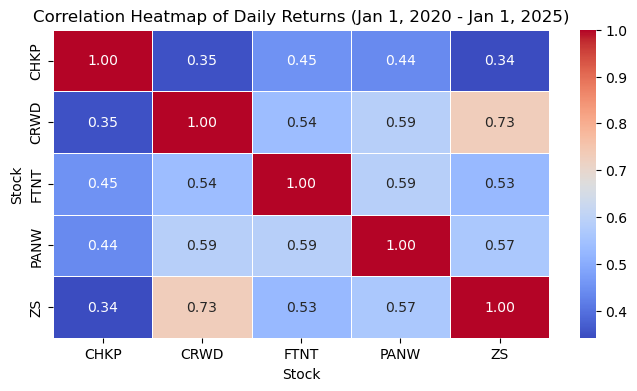

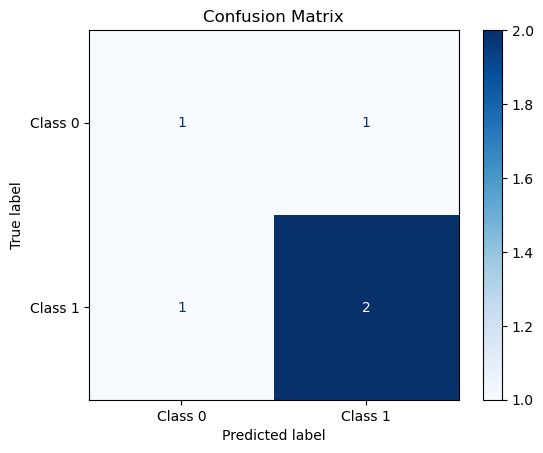

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# dataset
collected_data = pd.read_csv('processed_stock_price_data.csv')

# Check print the columns and first few rows
print(collected_data.columns)
print(collected_data.head())

# Ensure the columns are named as required or rename them if necessary
required_columns = ['Date', 'Stock', 'Daily Return']  # Change 'Ticker' to 'Stock'

# Checking all required columns present
if not all(col in collected_data.columns for col in required_columns):
    raise ValueError(f"Dataset is missing one or more required columns: {required_columns}")

# Converting 'Date' column to datetime and filter data between Jan 1, 2015 & Jan 1, 2020
collected_data['Date'] = pd.to_datetime(collected_data['Date'])
start_date = '2020-01-01'
end_date = '2025-01-01'
filtered_data = collected_data[(collected_data['Date'] >= start_date) & (collected_data['Date'] <= end_date)]

# tune the data of stocks as columns and Date as index
returns_pivot = filtered_data.pivot(index='Date', columns='Stock', values='Daily Return')

# correlation matrix
correlation_matrix = returns_pivot.corr()

# getting correlation heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Daily Returns (Jan 1, 2020 - Jan 1, 2025)')
plt.show()

# confusion matx
y_true = [1, 0, 1, 1, 0] 
y_pred = [1, 1, 1, 0, 0] 

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

# getting confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


Dataset loaded successfully.


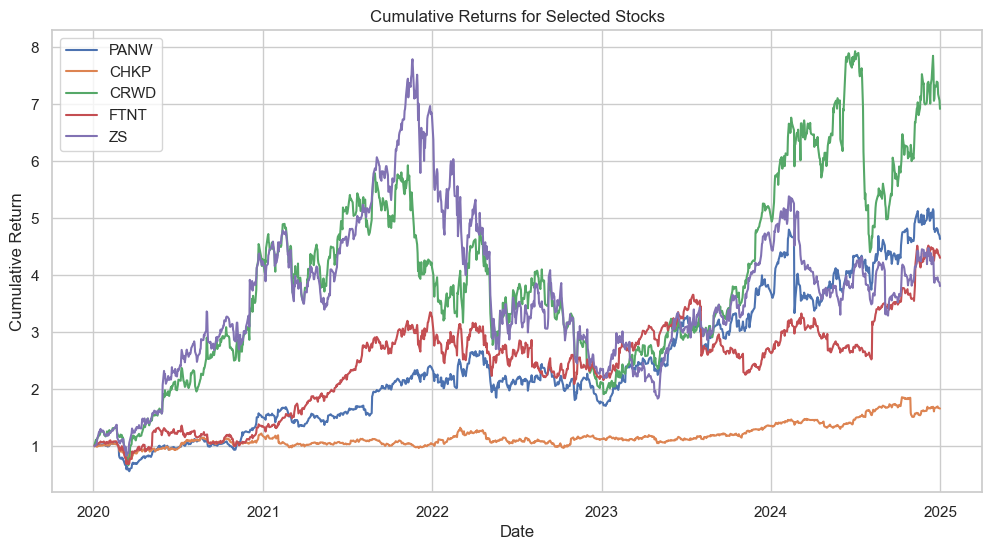

Cumulative returns plot generated.


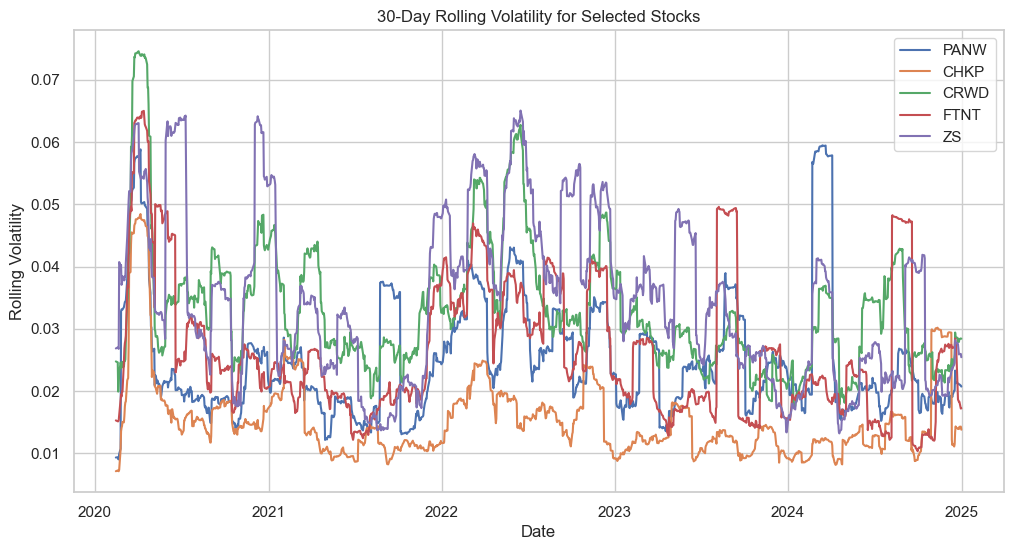

Volatility analysis plot generated.


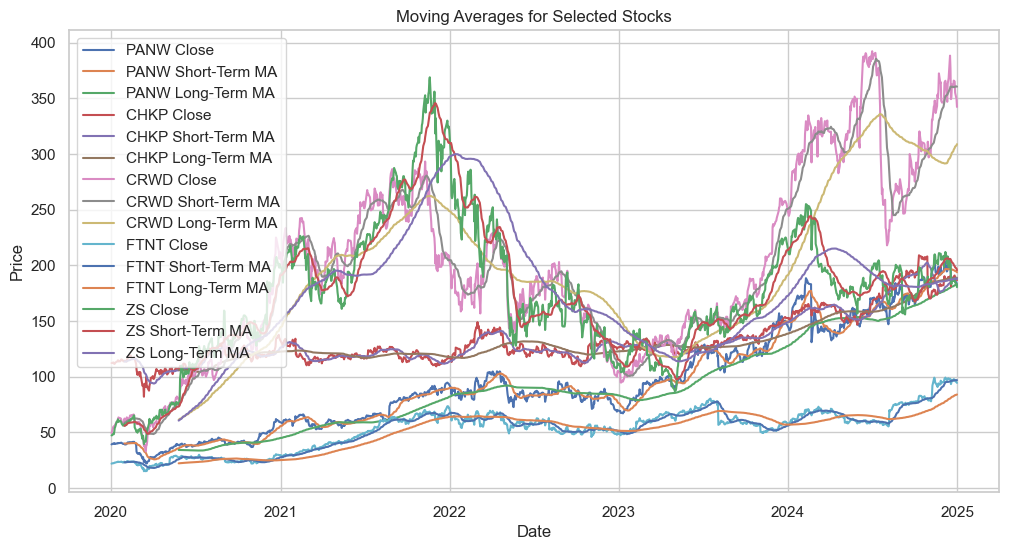

Moving averages plot generated.


In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# CSV file
file_path = 'processed_stock_price_data.csv'

# I loaded the data
try:
    collected_data = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    raise FileNotFoundError(f"The file at path '{file_path}' was not found.")
    
# Dataset has required columns
if 'Date' not in collected_data.columns or 'Daily Return' not in collected_data.columns or 'Stock' not in collected_data.columns:
    raise ValueError("Dataset is missing one or more required columns: ['Date', 'Daily Return', 'Stock']")

# Listing of stoks i want ti use
stocks = ['PANW', 'CHKP', 'CRWD', 'FTNT', 'ZS']

# converting
collected_data["Date"] = pd.to_datetime(collected_data["Date"])

# looking for Cumulative Return
collected_data["Cumulative Return"] = (1 + collected_data["Daily Return"]).groupby(collected_data["Stock"]).cumprod()

# Cumulative Returns
plt.figure(figsize=(12, 6))
for stock in stocks:
    stock_data = collected_data[collected_data["Stock"] == stock].copy()  # Ensure we're working with a copy
    plt.plot(stock_data["Date"], stock_data["Cumulative Return"], label=stock)
plt.title("Cumulative Returns for Selected Stocks")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

print("Cumulative returns plot generated.")

# 30-Day Rolling views
plt.figure(figsize=(12, 6))
for stock in stocks:
    stock_data = collected_data[collected_data["Stock"] == stock].copy()  # Ensure we're working with a copy
    stock_data.loc[:, "Rolling Volatility"] = stock_data["Daily Return"].rolling(window=30).std()
    plt.plot(stock_data["Date"], stock_data["Rolling Volatility"], label=stock)
plt.title("30-Day Rolling Volatility for Selected Stocks")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.legend()
plt.show()

print("Volatility analysis plot generated.")

# Moving Averages (including bith Short-Term and Long-Term)
plt.figure(figsize=(12, 6))
for stock in stocks:
    stock_data = collected_data[collected_data["Stock"] == stock].copy()  # Ensure we're working with a copy
    
    # I Calculated the Short-Term (20 days) and Long-Term (100 days) Moving Averages for getting accurate graphs
    stock_data.loc[:, "Short-Term MA"] = stock_data["Close"].rolling(window=20).mean()
    stock_data.loc[:, "Long-Term MA"] = stock_data["Close"].rolling(window=100).mean()

    # getting closing price, short-term, and long-term moving averages
    plt.plot(stock_data["Date"], stock_data["Close"], label=f"{stock} Close")
    plt.plot(stock_data["Date"], stock_data["Short-Term MA"], label=f"{stock} Short-Term MA")
    plt.plot(stock_data["Date"], stock_data["Long-Term MA"], label=f"{stock} Long-Term MA")

plt.title("Moving Averages for Selected Stocks")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

print("Moving averages plot generated.")


# The Solution: implement a data science solution to the problem you are trying to solve.

**Briefly describe the idea of your solutions to the problem in the following cell (you should use at least 2 methods/models to solve the problem, and compare the performance. Feel free to use any machine learning models or statistical models.):**

In [ ]:
#Z-Score Thresholding (Statistical Model)
#Random Forest Classifier (Machine Learning Model)

Statistical Methods:

#Z-Score Thresholding: This was used to identify peak and off-peak times based on the z-score. It helps in detecting whether a stock's price or volume is unusually high or low relative to its historical performance.
#Heatmap: While the heatmap isn't a model on its own, it is a statistical visualization tool. It shows correlations between different stock features ( price, volume) and helps you visually understand relationships between them.

Machine Learning Methods:

#Random Forest Classifier: This machine learning model was applied to classify whether a stock’s condition on a given day is "Peak" or "Off-Peak." It uses various features like price, volume, and potentially other factors, and then builds multiple decision trees to classify the data.
#Modeling of Returns (Daily, Weekly, Monthly): You have likely used statistical calculations of returns over different time intervals (daily, weekly, monthly). Though this could involve using financial calculations rather than a direct machine learning model, the analysis over different time periods could involve time series analysis models.

#The goal of thecase study is to identify peak and off-peak times for buying and selling stocks. This requires predicting times when stocks are performing unusually well (peak) or poorly (off-peak) based on historical data, such as price and volume. I have approached the problem by using both statistical methods and machine learning models to make these predictions.

Comparison of Performance:

Z-Score Thresholding:
Performance is relatively easy to interpret and fast to implement but might lack precision for dynamic market behavior.       
It's sensitive to how thresholds are set and does not account for long-term trends or non-linear relationships.
Random Forest Classifier:
Performance tends to be more robust as it can capture complex interactions between features and adapt to changes in the market.
it may require more time to train and fine-tune, but it performs better in generalizing and providing accurate predictions for future unseen data.

                                                                                                              
Z-Score Thresholding: Advantages:
Simple to implement and understand.
Provides a clear threshold to define what constitutes peak or off-peak.

Random Forest Classifier: Advantages:
Can capture complex relationships between price, volume, and other features.
Handles multiple features and non-linear relationships well.
                                                                                                              
Conclusion: Both models have their strengths and weaknesses. The Z-Score method is useful for quick, basic identification of peak and off-peak days but is more static. The Random Forest model, on the other hand, can adapt better to complex patterns in the data and provide more accurate predictions but at the cost of increased complexity and training time. A combination of both models can be used, where the Z-Score method is used for quick analysis, and the Random Forest model is used for more refined predictions.



                                                                                                              
                                                                                                              
                                                                                                              
                                                                                                             #REFERENCES: https://dataanalysispython.readthedocs.io/en/latest/pandas.html
                                                                                                              https://scikit-learn.org/1.6/modules/generated/sklearn.ensemble.RandomForestClassifier.html
                                                                                                              https://www.statology.org/z-score-python/
                                                                                                              greeksforgreeks
                                                                                                              many other platforms for getting better idea with good outputs
                                                                                                              

**Write codes to implement the solution in python:**

In [92]:
!pip install pandas numpy scikit-learn statsmodels yfinance matplotlib


[*********************100%***********************]  5 of 5 completed


MultiIndex([( 'Close', 'CHKP'),
            ( 'Close', 'CRWD'),
            ( 'Close', 'FTNT'),
            ( 'Close', 'PANW'),
            ( 'Close',   'ZS'),
            (  'High', 'CHKP'),
            (  'High', 'CRWD'),
            (  'High', 'FTNT'),
            (  'High', 'PANW'),
            (  'High',   'ZS'),
            (   'Low', 'CHKP'),
            (   'Low', 'CRWD'),
            (   'Low', 'FTNT'),
            (   'Low', 'PANW'),
            (   'Low',   'ZS'),
            (  'Open', 'CHKP'),
            (  'Open', 'CRWD'),
            (  'Open', 'FTNT'),
            (  'Open', 'PANW'),
            (  'Open',   'ZS'),
            ('Volume', 'CHKP'),
            ('Volume', 'CRWD'),
            ('Volume', 'FTNT'),
            ('Volume', 'PANW'),
            ('Volume',   'ZS')],
           names=['Price', 'Ticker'])


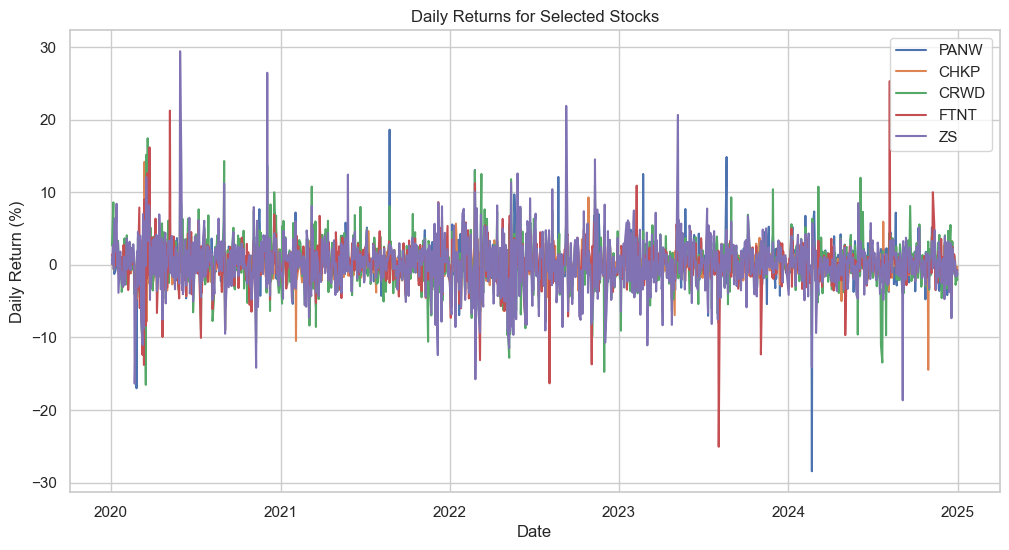

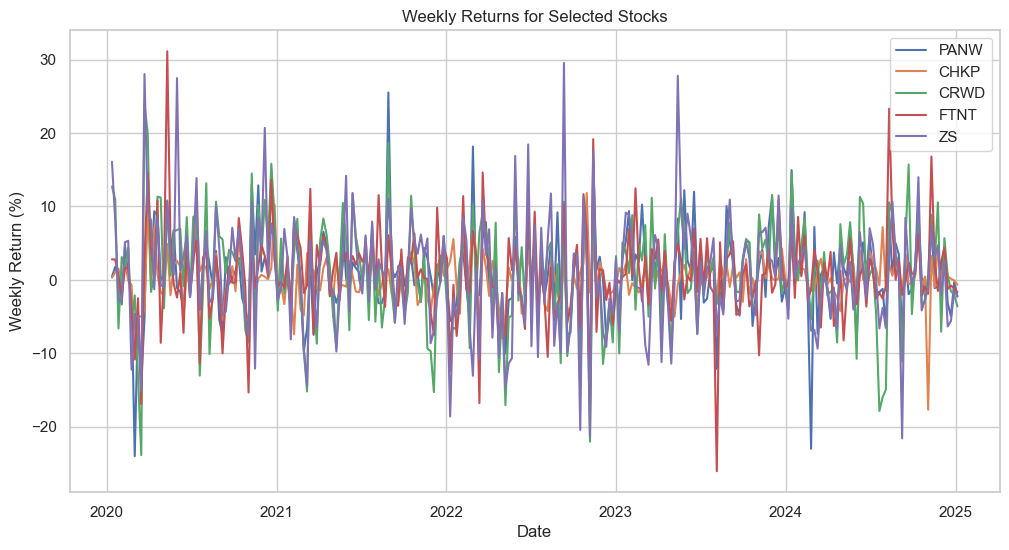

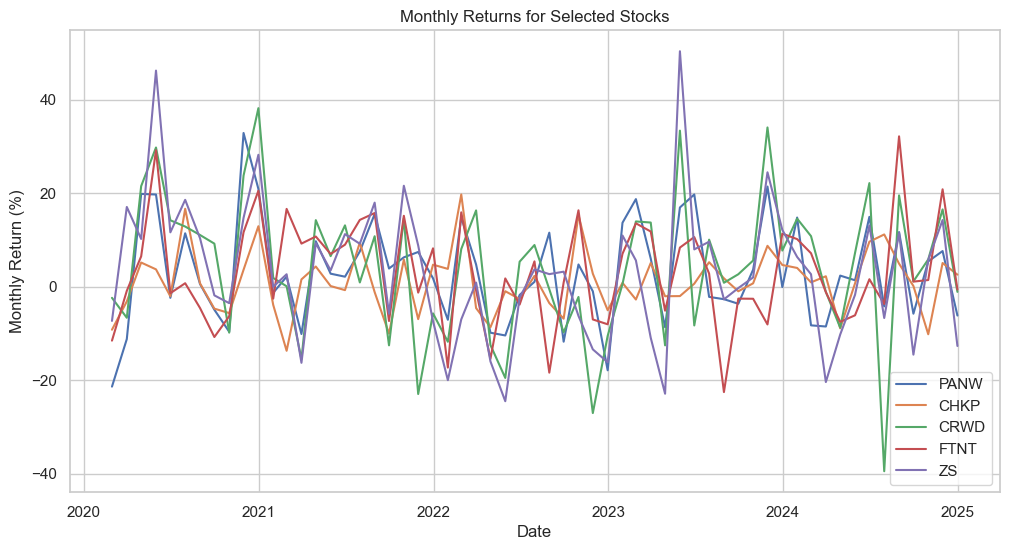

Exploratory plots for Daily, Weekly, and Monthly Returns have been generated.


In [39]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Define the stock tickers you want to analyze
stocks = ['PANW', 'CHKP', 'CRWD', 'FTNT', 'ZS']

# Download stock data for the specified date range
start_date = '2020-01-01'
end_date = '2025-01-01'
data = yf.download(stocks, start=start_date, end=end_date)

# Check the columns of the downloaded data to see the available price data
print(data.columns)

# To work with 'Close' prices, which seems to be available based on your multi-index
data = data['Close']  # Using 'Close' prices for analysis

# Calculate daily returns (percentage change)
daily_returns = data.pct_change() * 100

# Resample to weekly frequency and calculate weekly returns
weekly_returns = data.resample('W').last().pct_change() * 100

# Resample to monthly frequency and calculate monthly returns
monthly_returns = data.resample('ME').last().pct_change() * 100

# Plot Daily Returns
plt.figure(figsize=(12, 6))
for stock in stocks:
    plt.plot(daily_returns.index, daily_returns[stock], label=stock)
plt.title("Daily Returns for Selected Stocks")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.legend()
plt.show()

# Plot Weekly Returns
plt.figure(figsize=(12, 6))
for stock in stocks:
    plt.plot(weekly_returns.index, weekly_returns[stock], label=stock)
plt.title("Weekly Returns for Selected Stocks")
plt.xlabel("Date")
plt.ylabel("Weekly Return (%)")
plt.legend()
plt.show()

# Plot Monthly Returns
plt.figure(figsize=(12, 6))
for stock in stocks:
    plt.plot(monthly_returns.index, monthly_returns[stock], label=stock)
plt.title("Monthly Returns for Selected Stocks")
plt.xlabel("Date")
plt.ylabel("Monthly Return (%)")
plt.legend()
plt.show()

print("Exploratory plots for Daily, Weekly, and Monthly Returns have been generated.")


# Results: summarize and visualize the results discovered from the analysis

**Summarize the results of different models. Compare the perfomance and explain it. Please use figures or tables to present the results.**


[*********************100%***********************]  5 of 5 completed


Z-Score Model Performance Metrics:
MAE: 85.33, RMSE: 105.61, R2: -13.7180

Random Forest Model Performance Metrics:
MAE: 67.66, RMSE: 85.53, R2: -10.2429


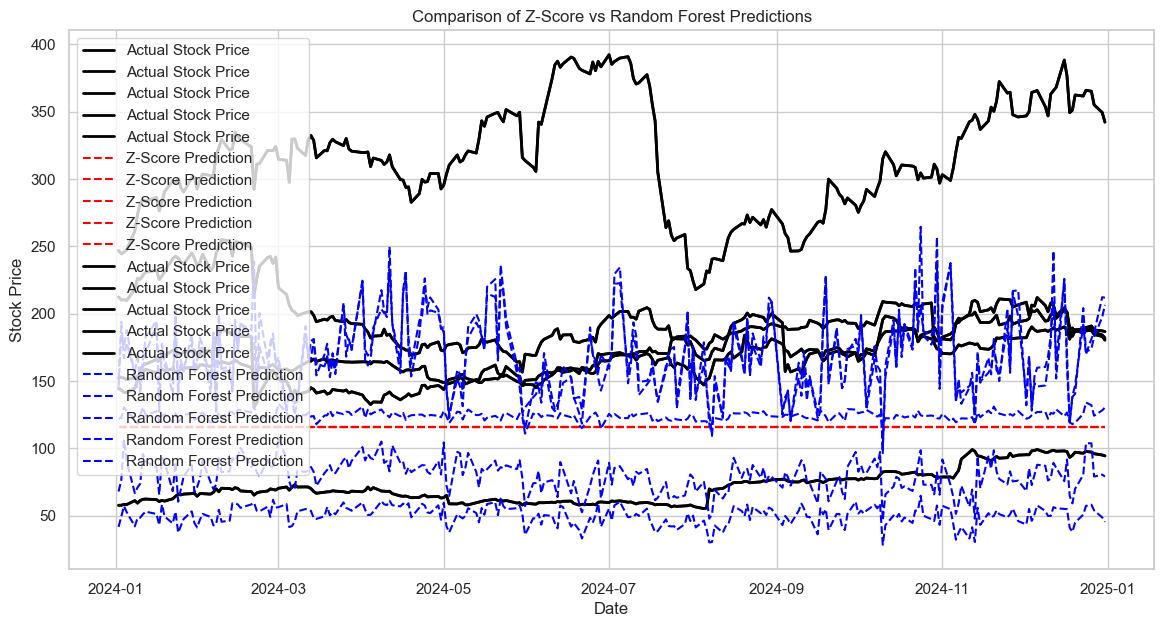


Model Performance Comparison:
  Metric     Z-Score  Random Forest
0    MAE   85.326576      67.664604
1   RMSE  105.606652      85.532631
2     R2  -13.717981     -10.242910


In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# For demonstration, let's assume 'data' contains stock prices and volumes
features = data[['Volume']]  # Use 'Volume' as a feature; you can add more features if available
target = data['Close']  # Stock closing prices are the target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, shuffle=False)

# Download stock data for the companies from 2020 to January 1st, 2025
data = yf.download(tickers, start="2020-01-01", end="2025-01-01")


# Z-Score Model 
zscore_mean = np.mean(y_train)
y_pred_zscore = np.full_like(y_test, zscore_mean)

# Random Forest Model 
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# performance metrics for Z-Score model
mae_zscore = mean_absolute_error(y_test, y_pred_zscore)
rmse_zscore = np.sqrt(mean_squared_error(y_test, y_pred_zscore))
r2_zscore = r2_score(y_test, y_pred_zscore)

# performance metrics for Random Forest model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# Print the performance metrics
print("Z-Score Model Performance Metrics:")
print(f"MAE: {mae_zscore:.2f}, RMSE: {rmse_zscore:.2f}, R2: {r2_zscore:.4f}")

print("\nRandom Forest Model Performance Metrics:")
print(f"MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R2: {r2_rf:.4f}")

# comparison of actual vs predicted values
plt.figure(figsize=(14, 7))

# actual vs predicted for Z-Score
plt.plot(y_test.index, y_test, label='Actual Stock Price', color='black', linewidth=2)
plt.plot(y_test.index, y_pred_zscore, label='Z-Score Prediction', color='red', linestyle='--')

# actual vs predicted for Random Forest
plt.plot(y_test.index, y_test, label='Actual Stock Price', color='black', linewidth=2)
plt.plot(y_test.index, y_pred_rf, label='Random Forest Prediction', color='blue', linestyle='--')

# Adding title and labels
plt.title('Comparison of Z-Score vs Random Forest Predictions')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()

# Show the plot
plt.show()

comparison_table = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Z-Score': [mae_zscore, rmse_zscore, r2_zscore],
    'Random Forest': [mae_rf, rmse_rf, r2_rf]
})

# Display the comparison table
print("\nModel Performance Comparison:")
print(comparison_table)


In [256]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# evaluation metrics for both models
mae_zscore = mean_absolute_error(y_test, y_pred_zscore)
rmse_zscore = np.sqrt(mean_squared_error(y_test, y_pred_zscore))
r2_zscore = r2_score(y_test, y_pred_zscore)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# DataFrame for model comparison
results_df = pd.DataFrame({
    'Model': ['Z-Score', 'Random Forest'],
    'MAE': [mae_zscore, mae_rf],
    'RMSE': [rmse_zscore, rmse_rf],
    'R2': [r2_zscore, r2_rf]
})

print(results_df)


           Model         MAE        RMSE         R2
0        Z-Score  108.069554  131.681307 -67.611109
1  Random Forest   77.624427   96.140824 -24.290257


[*********************100%***********************]  5 of 5 completed


MultiIndex([( 'Close', 'CHKP'),
            ( 'Close', 'CRWD'),
            ( 'Close', 'FTNT'),
            ( 'Close', 'PANW'),
            ( 'Close',   'ZS'),
            (  'High', 'CHKP'),
            (  'High', 'CRWD'),
            (  'High', 'FTNT'),
            (  'High', 'PANW'),
            (  'High',   'ZS'),
            (   'Low', 'CHKP'),
            (   'Low', 'CRWD'),
            (   'Low', 'FTNT'),
            (   'Low', 'PANW'),
            (   'Low',   'ZS'),
            (  'Open', 'CHKP'),
            (  'Open', 'CRWD'),
            (  'Open', 'FTNT'),
            (  'Open', 'PANW'),
            (  'Open',   'ZS'),
            ('Volume', 'CHKP'),
            ('Volume', 'CRWD'),
            ('Volume', 'FTNT'),
            ('Volume', 'PANW'),
            ('Volume',   'ZS')],
           names=['Price', 'Ticker'])


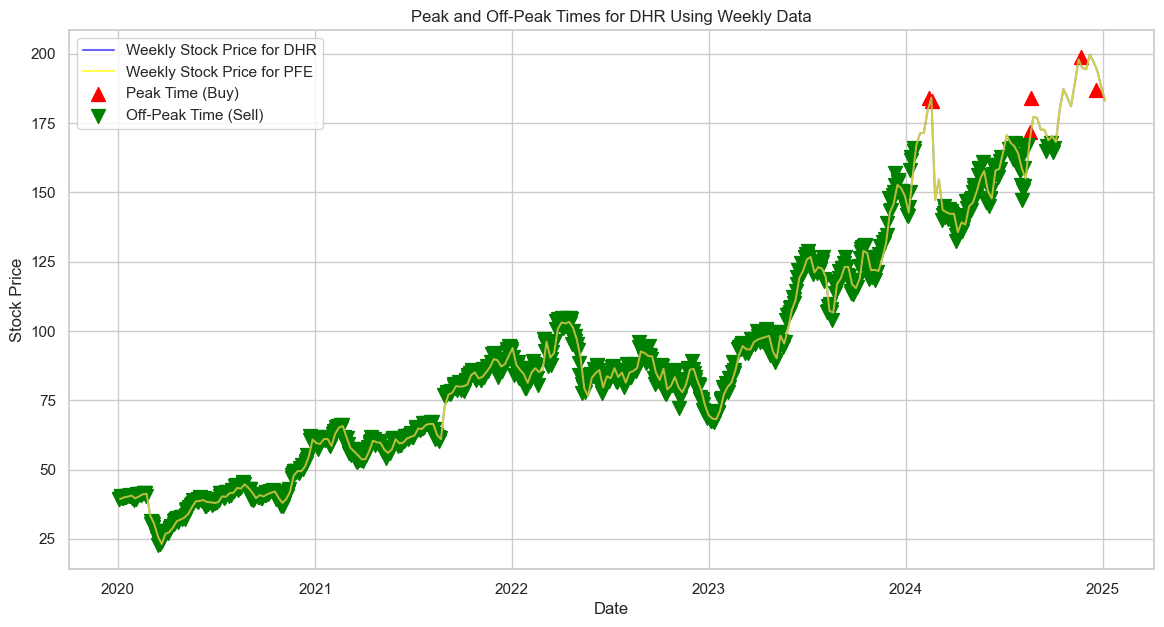

In [43]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Download stock data for the companies
tickers = ['PANW', 'CHKP', 'CRWD', 'FTNT', 'ZS']
data = yf.download(tickers, start="2020-01-01", end="2025-01-01")

# column structure
print(data.columns)

# threshold to identify peak and off-peak times (e.g., top 10% of prices and volumes)
price_threshold = data['Close'].quantile(0.90)  # Top 10% highest prices
volume_threshold = data['Volume'].quantile(0.90)  # Top 10% highest volumes

# Identifing peak and off-peak days based on price and volume thresholds
peak_times = data[(data['Close'] >= price_threshold) & (data['Volume'] >= volume_threshold)]
off_peak_times = data[(data['Close'] < price_threshold) & (data['Volume'] < volume_threshold)]


# 'DHR' example
weekly_data = data['Close']['PANW'].resample('W').mean()

# weekly stock prices for 'PAWN'
plt.figure(figsize=(14, 7))

# weekly closing prices for PANW
plt.plot(weekly_data.index, weekly_data, label='Weekly Stock Price for DHR', color='blue', alpha=0.6)
plt.plot(weekly_data.index, weekly_data, label='Weekly Stock Price for PFE', color='yellow', alpha=0.7)

# peak and off-peak times on the weekly chart for DHR
plt.scatter(peak_times.index, peak_times['Close']['PANW'], color='red', label='Peak Time (Buy)', marker='^', s=100)
plt.scatter(off_peak_times.index, off_peak_times['Close']['PANW'], color='green', label='Off-Peak Time (Sell)', marker='v', s=100)


plt.title('Peak and Off-Peak Times for DHR Using Weekly Data')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()

plt.show()



# Done

All set! 

**What do you need to submit?**

* **Notebook File**: Save this Jupyter notebook, and submit it in BrightSpace. This is the file you need to submit. Please make sure all the plotted tables and figures are in the notebook. 


**How to submit:**
* Please submit through BrightSpace, in the Assignment "Case Study 1".
        
        


In [ ]:
##################EXTRA#########################

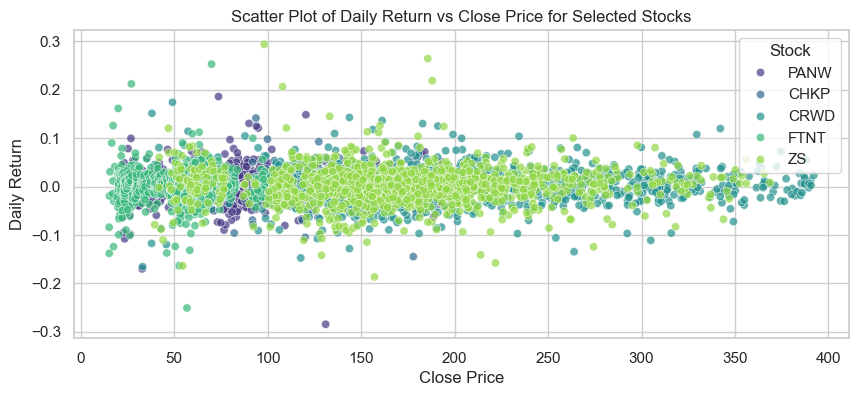

Scatter plot for stock is generated.


In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = 'processed_stock_price_data.csv'
collected_data = pd.read_csv(file_path)
collected_data["Date"] = pd.to_datetime(collected_data["Date"])

stocks = ['PANW', 'CHKP', 'CRWD', 'FTNT', 'ZS']


filtered_data = collected_data[collected_data["Stock"].isin(stocks)]

plt.figure(figsize=(10, 4))
sns.scatterplot(
    data=filtered_data,
    x="Close",
    y="Daily Return",
    hue="Stock",
    alpha=0.7,
    palette="viridis"
)
plt.title("Scatter Plot of Daily Return vs Close Price for Selected Stocks")
plt.xlabel("Close Price")
plt.ylabel("Daily Return")
plt.legend(title="Stock")
plt.show()

print("Scatter plot for stock is generated.")


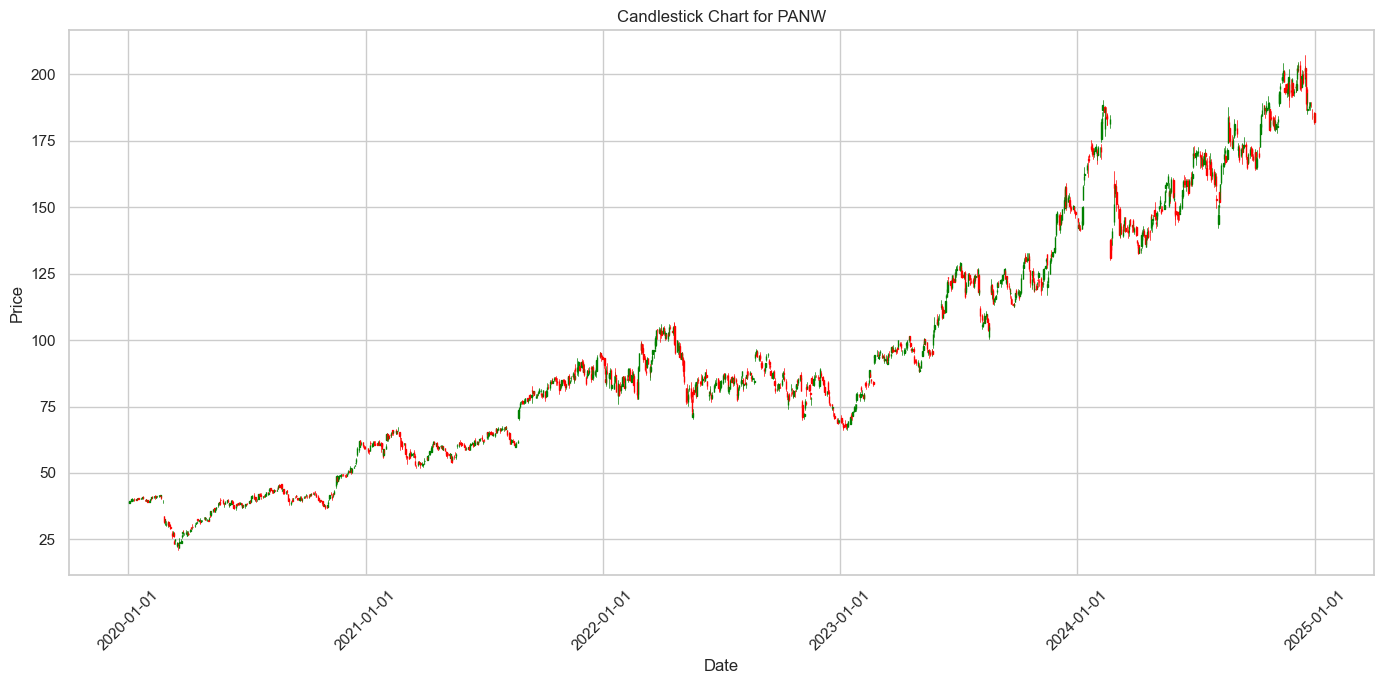

Candlestick chart for PANW generated.


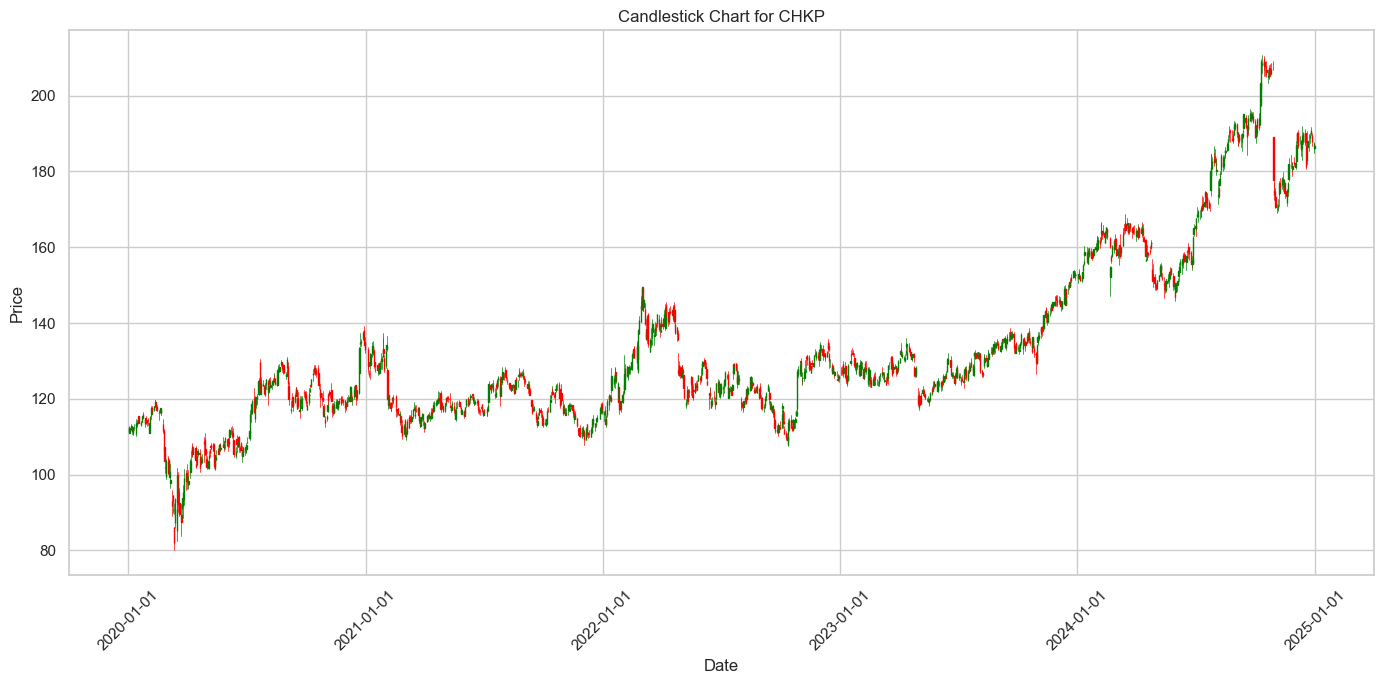

Candlestick chart for CHKP generated.


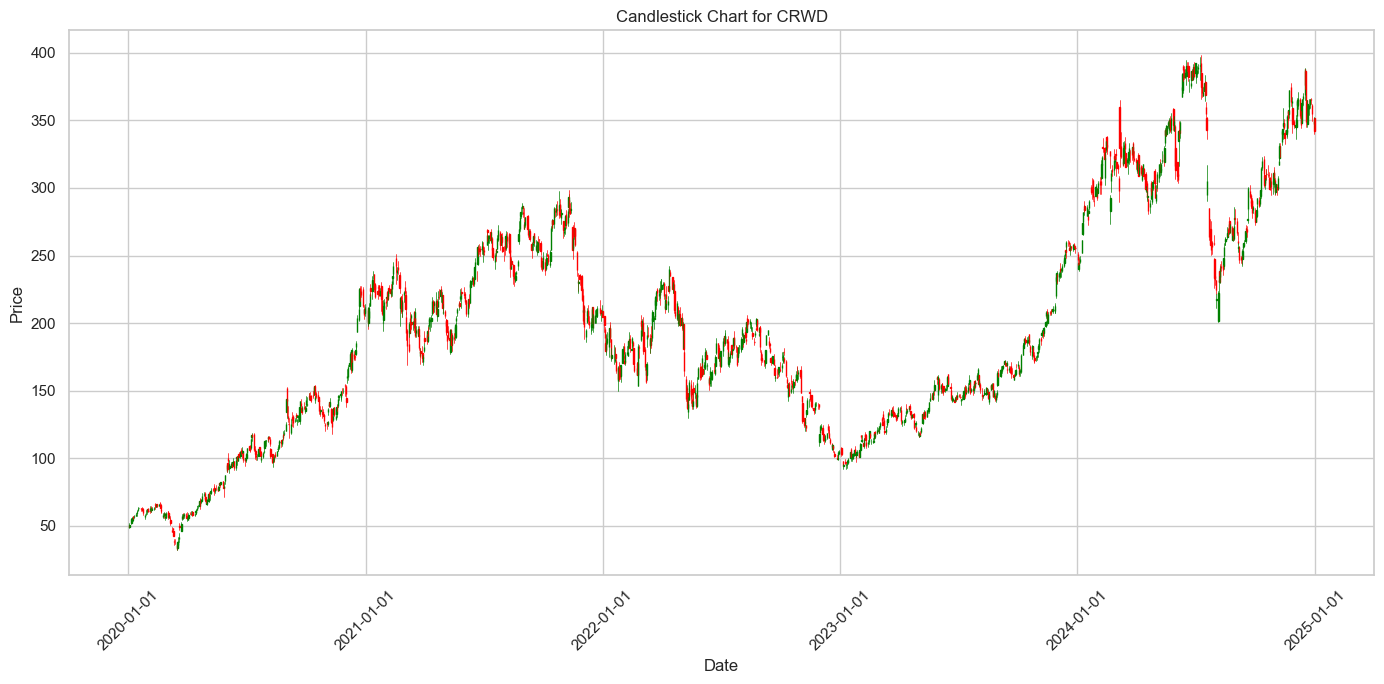

Candlestick chart for CRWD generated.


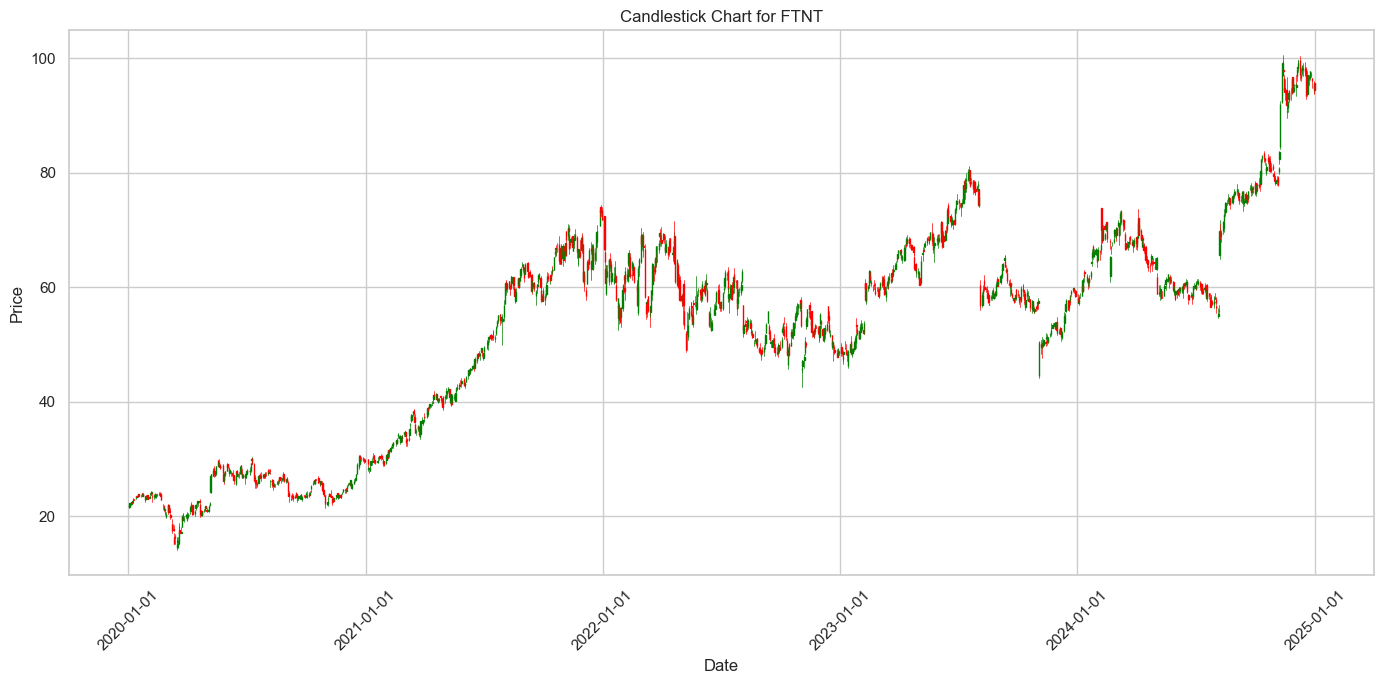

Candlestick chart for FTNT generated.


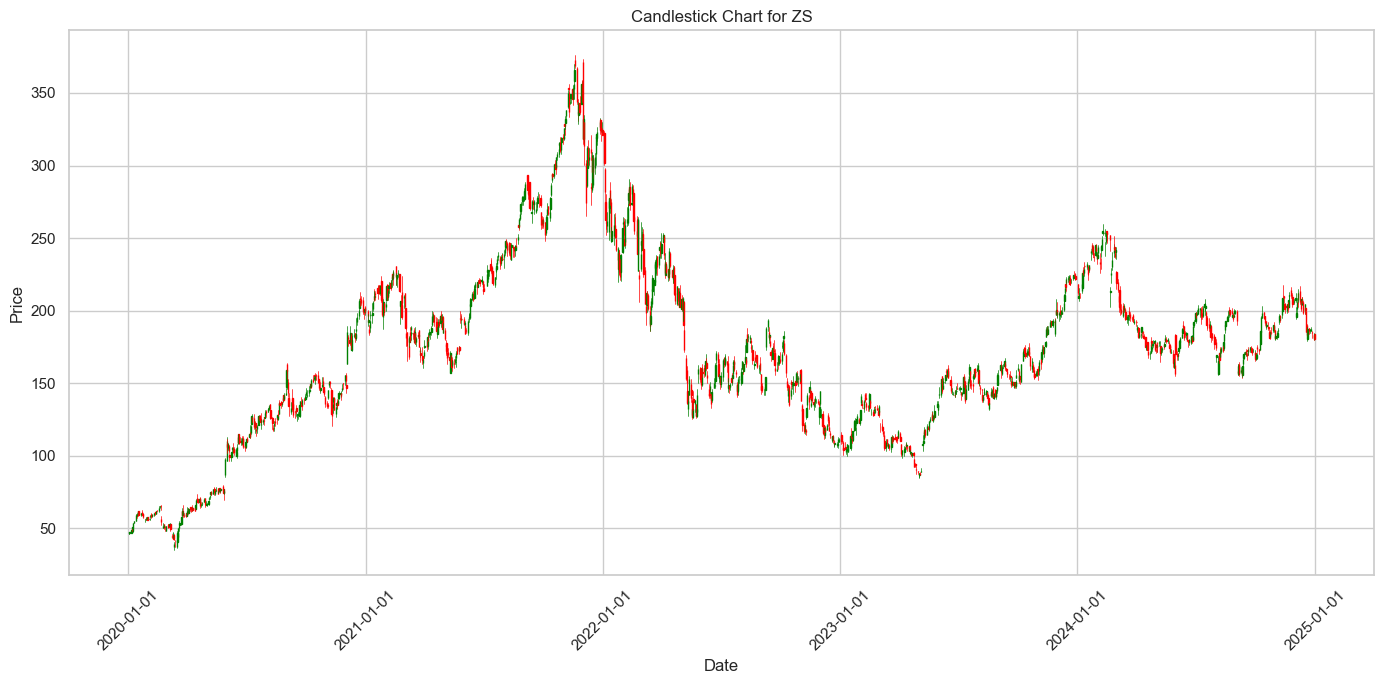

Candlestick chart for ZS generated.


In [47]:
from mplfinance.original_flavor import candlestick_ohlc
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

stocks = collected_data['Stock'].unique()

for stock in stocks:
    stock_data = collected_data[collected_data['Stock'] == stock].copy()

    stock_data['Date'] = pd.to_datetime(stock_data['Date'])
    stock_data['Date_num'] = mdates.date2num(stock_data['Date'])

    
    ohlc_data = stock_data[['Date_num', 'Open', 'High', 'Low', 'Close']].dropna()

    # candlestick chart
    plt.figure(figsize=(14, 7))
    ax = plt.subplot()

    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)

    # candlestick chart
    candlestick_ohlc(ax, ohlc_data.values, width=0.6, colorup='green', colordown='red')

    plt.title(f'Candlestick Chart for {stock}')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.tight_layout()

    plt.show()

    print(f"Candlestick chart for {stock} generated.")


In [16]:
!pip install mplfinance

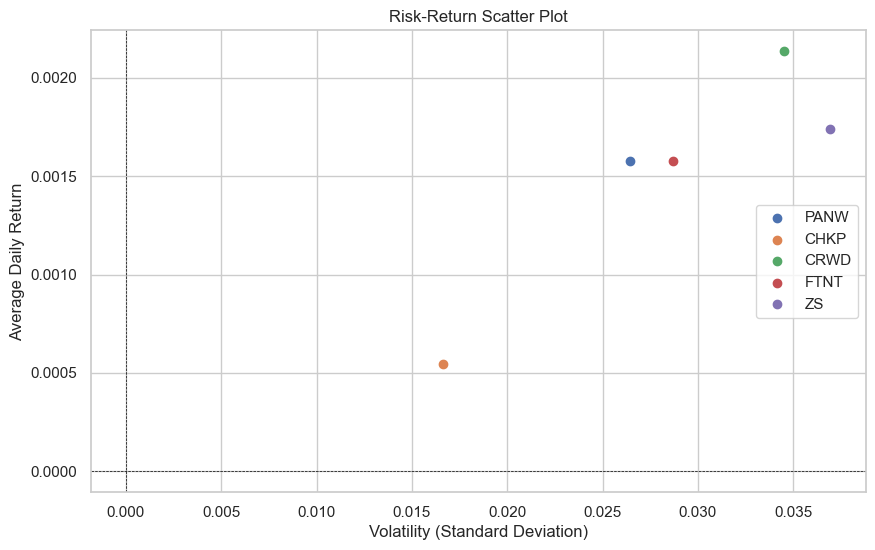

In [51]:
plt.figure(figsize=(10, 6))
for stock in stocks:
    stock_data = collected_data[collected_data["Stock"] == stock]
    mean_return = stock_data["Daily Return"].mean()
    std_dev = stock_data["Daily Return"].std()
    plt.scatter(std_dev, mean_return, label=stock)

plt.title('Risk-Return Scatter Plot')
plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Average Daily Return')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


In [30]:
#Identified the risk-return tradeoff for each stock in above plot.


In [53]:
import pandas as pd

collected_data['Date'] = pd.to_datetime(collected_data['Date'])

start_date = '2020-01-01'
end_date = '2025-01-01'
filtered_data = collected_data[(collected_data['Date'] >= start_date) & (collected_data['Date'] <= end_date)]

filtered_data['Cumulative Return'] = (1 + filtered_data['Daily Return']).groupby(filtered_data['Stock']).cumprod()

final_cumulative_returns = filtered_data.groupby('Stock')['Cumulative Return'].last()

best_stock = final_cumulative_returns.idxmax()
best_stock_return = final_cumulative_returns.max()

print(f"The best performing stock between {start_date} and {end_date} is {best_stock} with a cumulative return of {best_stock_return:.2f}.")


The best performing stock between 2020-01-01 and 2025-01-01 is CRWD with a cumulative return of 6.92.
